### Ordinary Least Square with bootstrapping error estimation

We have a real dataset $I-V$ for Ohm's law:

$$
    V = R \, I
$$

We want to fit the dataset to find R. We'll implement OLS method + boostrapping error estimation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as smp

plt.style.use('dark_background')

In [2]:
# Real dataset I-V
I_data = np.array([0, 0.544, 1.134, 1.632, 2.5, 3.07, 3.64, 4.22, 4.89, 5.45, 6.07, 6.66, 7.34, 7.91], dtype = np.float32) # milli-Ampere
V_data = np.arange(0.0, 7.0, 0.5, dtype = np.float32) # Volt

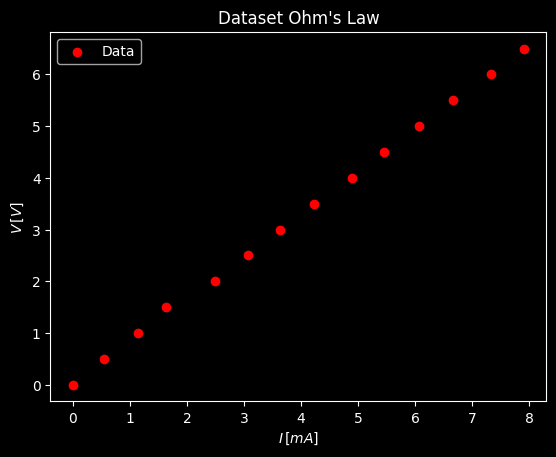

In [3]:
# Dataset plotting
plt.title("Dataset Ohm's Law")
plt.scatter(I_data, V_data, color = 'red', label = 'Data')
plt.xlabel(r'$I \, [mA]$')
plt.ylabel(r'$V \, [V]$')
plt.legend(loc = 'best')
plt.show()

Let's find $R$ that minimizes the sum of squared residuals, as shown below:

$$
    \sum_{k = 1}^{N} \, \left( V_k - R \, I_k \right) ^ 2
$$

If we define the column vectors:

$$
    \vec{V} = \begin{pmatrix} V_1 \\ V_2 \\ \vdots \\ V_N \end{pmatrix} \qquad
    \vec{I} = \begin{pmatrix} I_1 \\ I_2 \\ \vdots \\ I_N \end{pmatrix}
$$

Then we can write the sum in vectorial form:

$$
    \sum_{k=1}^{N} (V_k - R I_k)^2 = \|\vec{V} - R\, \vec{I}\|^2 = (\vec{V} - R\, \vec{I}) \cdot (\vec{V} - R\, \vec{I})
$$

We'll use SymPy to find $R$

In [4]:
def sympy():
    k, N = smp.symbols('k N', integer = True, positive = True)
    R = smp.symbols('R', real = True, positive = True)
    V = smp.IndexedBase('V')
    I = smp.IndexedBase('I')
    Vk = V[k]
    Ik = I[k]

    res2 = (Vk - R * Ik) ** 2
    sum = smp.Sum(res2, (k, 1, N))

    ds_dR = (smp.diff(sum, R)).expand().cancel()
    solution = smp.solve(ds_dR, R)[0]

    return solution

sympy()

Sum(I[k]*V[k], (k, 1, N))/Sum(I[k]**2, (k, 1, N))

So, we need to compute:

$$
    R = \frac{\sum_{k = 1}^N \, V_k \, I_k}{\sum_{k = 1}^{N} \, I_k ^ 2}
$$

Or, in vectorial form (elegant):

$$
    R = \frac{\vec{V} \cdot \vec{I}}{\vec{I} \cdot \vec{I}}
$$

In [5]:
# Compute R using the formula [V / mA]
R_computed = np.dot(V_data, I_data) / np.dot(I_data, I_data)
R_computed

np.float32(0.8229932)

In [6]:
# Minimized sum of squared residuals
np.dot(V_data - R_computed * I_data, V_data - R_computed * I_data)

np.float32(0.039501842)

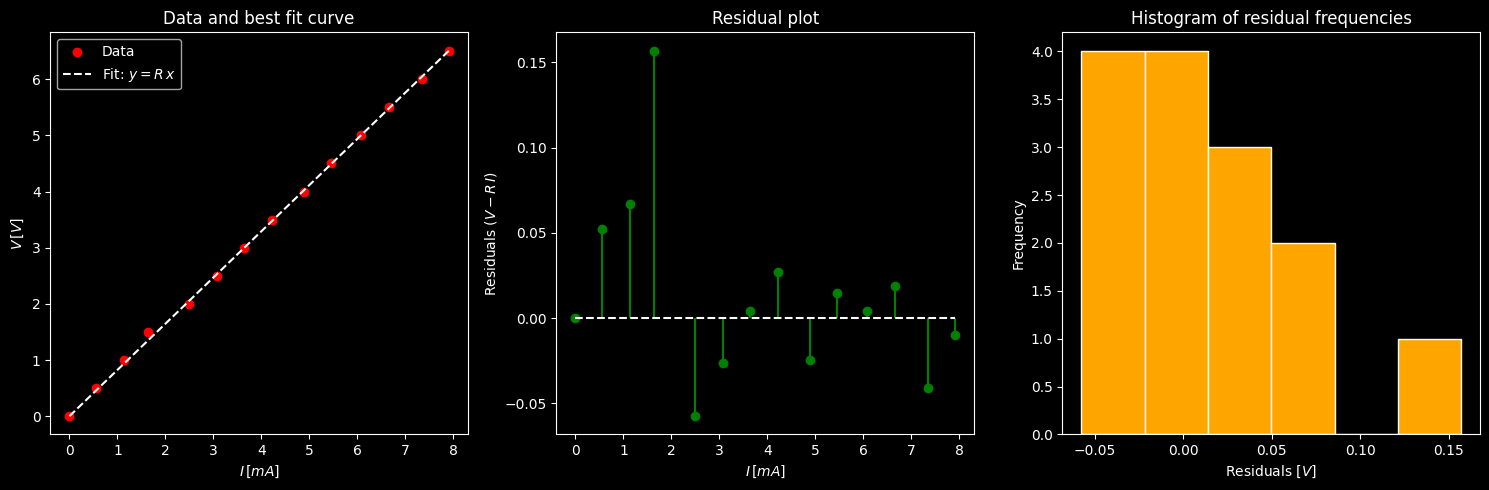

In [7]:
# Plotting results
fig, (ax_left, ax_right, ax_hist) = plt.subplots(1, 3, figsize = (15, 5))

# Data and fit plot
ax_left.scatter(I_data, V_data, color = 'red', label = 'Data')
ax_left.plot(I_data, R_computed * I_data, linestyle = '--', color = 'white', label = r'Fit: $y = R \, x$')
ax_left.set_xlabel(r'$I \, [mA]$')
ax_left.set_ylabel(r'$V \, [V]$')
ax_left.set_title('Data and best fit curve')
ax_left.legend()

# Residuals plot
res = V_data - R_computed * I_data
ax_right.stem(I_data, res, linefmt =  'green', markerfmt = 'green', basefmt = 'w--', bottom = 0)
ax_right.set_xlabel(r'$I \, [mA]$')
ax_right.set_ylabel(r'Residuals $(V - R \, I)$')
ax_right.set_title('Residual plot')

# Residuals histogram plot
ax_hist.hist(res, bins = 'auto', density = False, color = 'orange', edgecolor = 'white')
ax_hist.set_xlabel(r'Residuals $[V]$')
ax_hist.set_ylabel('Frequency')
ax_hist.set_title('Histogram of residual frequencies')

plt.tight_layout()
plt.show()

Let's estimate the error $\Delta R$ using a bootstrapping method

In [8]:
def bootstrap(I_data, V_data, n_bootstrap = 25_000):

    n = len(I_data)

    IV = I_data * V_data
    I2 = I_data ** 2
    V2 = V_data ** 2

    indices = np.random.choice(n, size = (n_bootstrap, n), replace = True).astype(np.uint8) # Cut memory usage

    sum_IV = np.sum(IV[indices], axis = 1)
    sum_I2 = np.sum(I2[indices], axis = 1)
    sum_V2 = np.sum(V2[indices], axis = 1)

    R_array = sum_IV / sum_I2
    RSS_array = sum_V2 - 2 * R_array * sum_IV + (R_array ** 2) * sum_I2 # from vectorial form of the sum of squared residuals

    return (R_array, RSS_array)

R_array, RSS_array = bootstrap(I_data, V_data)

In [9]:
# Results for R, resistance in [V / mA] units
meanR = np.mean(R_array)
errR = np.std(R_array)
meanR, errR, errR / meanR * 100.0 # Mean, error and relative error

(np.float32(0.8231529), np.float32(0.0018231077), np.float32(0.22147861))

In [10]:
# Results for RSS, minimized sum of squared residuals
meanRSS = np.mean(RSS_array)
errRSS = np.std(RSS_array)
meanRSS, errRSS, errRSS / meanRSS * 100.0 # Mean, error and relative error

(np.float32(0.038731437), np.float32(0.022981416), np.float32(59.335304))

The boostrapping distribution of $R$ is not a simple gaussian. Let's see it

In [11]:
def gaussian(x, meanR, errR): # All float32
    one = np.float32(1.0)
    two = np.float32(2.0)
    half = np.float32(0.5)
    pi = np.float32(np.pi)

    norm = one / (np.sqrt(two * pi) * errR)
    exponent = - half * ((x - meanR) / errR) ** two
    gauss = norm * np.exp(exponent)

    return gauss

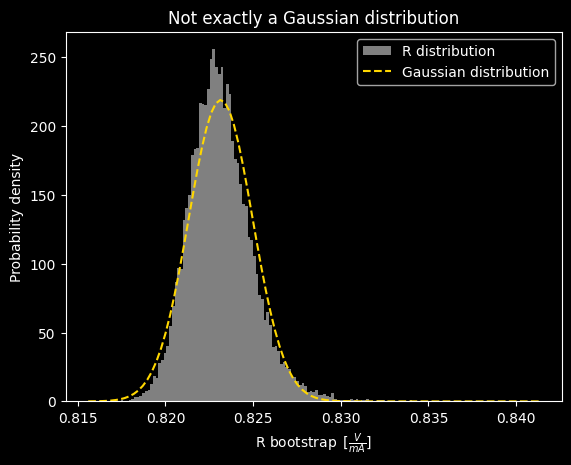

In [12]:
x = np.linspace(np.min(R_array), np.max(R_array), 100, dtype = np.float32)
dist = gaussian(x, meanR, errR)

plt.title('Not exactly a Gaussian distribution')
plt.hist(R_array, bins = 'auto', density = True, color = 'gray', label = 'R distribution')
plt.plot(x, dist, linestyle = '--', color = 'gold', label = 'Gaussian distribution')
plt.xlabel(r'R bootstrap $\, [\frac{V}{mA}]$')
plt.ylabel('Probability density')
plt.legend(loc = 'best')
plt.show()

The RSS distribution is more complicated

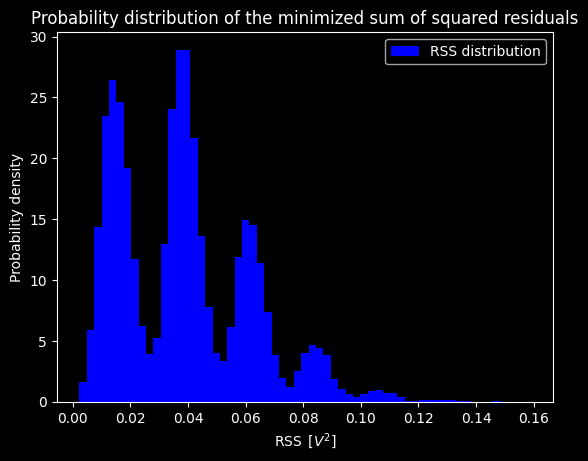

In [13]:
plt.title('Probability distribution of the minimized sum of squared residuals')
plt.hist(RSS_array, bins = 'auto', density = True, color = 'blue', label = 'RSS distribution')
plt.xlabel(r'RSS $\, [V ^{2}]$')
plt.ylabel('Probability density')
plt.legend(loc = 'best')
plt.show()

### Ordinary Least Square with jackknife error estimation

We want to fit a new real dataset to find R. We'll implement OLS method + jackknife error estimation

In [14]:
# Real dataset
I_data = np.array([0,0.071, 0.087, 0.098, 0.11, 0.122, 0.13, 0.14, 0.152, 0.163, 0.172, 0.18, 0.192, 0.202, 0.27, 0.37], dtype = np.float32) # milli-Ampere
V_data = np.array([0, 0.5, 1.0,1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 11.0, 14.7], dtype = np.float32) # Volt

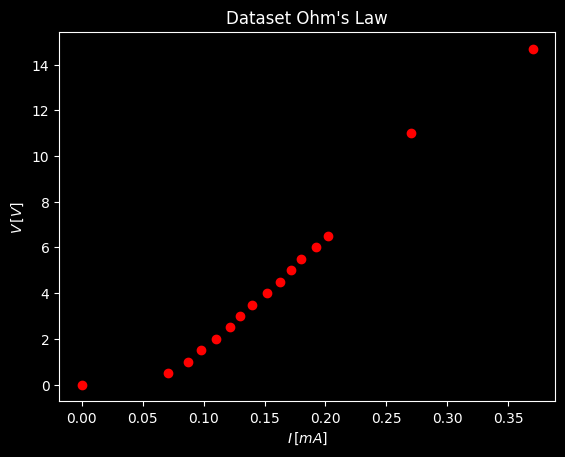

In [15]:
# New dataset plotting
plt.title("Dataset Ohm's Law")
plt.scatter(I_data, V_data, color = 'red')
plt.xlabel(r'$I \, [mA]$')
plt.ylabel(r'$V \, [V]$')
plt.show()

In [16]:
# Compute R using the vectorial formula [V / mA] (this dataset is messy)
R_computed = np.dot(V_data, I_data) / np.dot(I_data, I_data)
R_computed

np.float32(32.465454)

In [17]:
# Minimized sum of squared residuals
np.dot(V_data - R_computed * I_data, V_data - R_computed * I_data)

np.float32(30.83371)

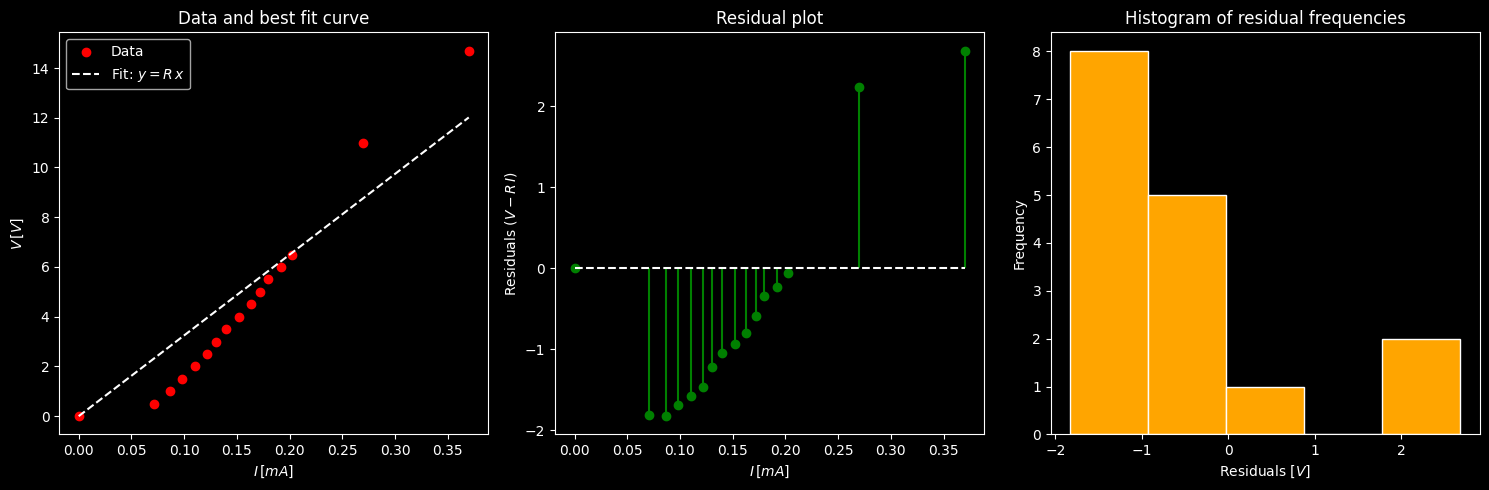

In [18]:
# Plotting results
fig, (ax_left, ax_right, ax_hist) = plt.subplots(1, 3, figsize = (15, 5))

# Data and fit plot
ax_left.scatter(I_data, V_data, color = 'red', label = 'Data')
ax_left.plot(I_data, R_computed * I_data, linestyle = '--', color = 'white', label = r'Fit: $y = R \, x$')
ax_left.set_xlabel(r'$I \, [mA]$')
ax_left.set_ylabel(r'$V \, [V]$')
ax_left.set_title('Data and best fit curve')
ax_left.legend()

# Residuals plot
res = V_data - R_computed * I_data
ax_right.stem(I_data, res, linefmt =  'green', markerfmt = 'green', basefmt = 'w--', bottom = 0)
ax_right.set_xlabel(r'$I \, [mA]$')
ax_right.set_ylabel(r'Residuals $(V - R \, I)$')
ax_right.set_title('Residual plot')

# Residuals histogram plot
ax_hist.hist(res, bins = 'auto', density = False, color = 'orange', edgecolor = 'white')
ax_hist.set_xlabel(r'Residuals $[V]$')
ax_hist.set_ylabel('Frequency')
ax_hist.set_title('Histogram of residual frequencies')

plt.tight_layout()
plt.show()

We must add an offset $q$ to get a better approximation

In [19]:
def sympy():
    k, N = smp.symbols('k N', integer = True, positive = True)
    R, q = smp.symbols('R q', real = True) # q is new
    V = smp.IndexedBase('V')
    I = smp.IndexedBase('I')
    Vk = V[k]
    Ik = I[k]

    res2 = (Vk - R * Ik - q) ** 2
    sum = smp.Sum(res2, (k, 1, N))

    ds_dR = (smp.diff(sum, R)).expand().cancel()
    ds_dq = (smp.diff(sum, q)).expand().cancel()
    solution = smp.solve([ds_dR, ds_dq], [R, q])

    sol_R = solution[R].simplify()
    sol_q = solution[q].simplify()

    return (sol_R, sol_q)

sol_R, sol_q = sympy()

In [20]:
sol_R

Sum(-I[k]*Sum(V[k], (k, 1, N)) + Sum(I[k]*V[k], (k, 1, N)), (k, 1, N))/(N*Sum(I[k]**2, (k, 1, N)) - Sum(I[k], (k, 1, N))**2)

In [21]:
sol_q

Sum((I[k]*Sum(V[k], (k, 1, N)) - V[k]*Sum(I[k], (k, 1, N)))*I[k], (k, 1, N))/(N*Sum(I[k]**2, (k, 1, N)) - Sum(I[k], (k, 1, N))**2)

The vectorial form is easier. We can write:

$$
    R = \frac{\tilde{\mathbf{I}} \cdot \tilde{\mathbf{V}}}{\tilde{\mathbf{I}} \cdot \tilde{\mathbf{I}}}
    \qquad\text{and}\qquad
    q = \bar{V} - R \, \bar{I}
$$

Where:

$$
    \tilde{\mathbf{I}} = \vec{I} - \bar{I} \, \vec{1}, \qquad
    \tilde{\mathbf{V}} = \vec{V} - \bar{V} \, \vec{1}
$$

And:

$$
    \bar{I} = \frac{1}{N} \vec{I} \cdot \vec{1}, \qquad
    \bar{V} = \frac{1}{N} \vec{V} \cdot \vec{1}
$$

In [22]:
# Computing R and q using vectorial formulas (easy!)
I_bar = np.mean(I_data)
V_bar = np.mean(V_data)
I_tilde = I_data - I_bar
V_tilde = V_data - V_bar
R_computed = np.dot(V_tilde, I_tilde) / np.dot(I_tilde, I_tilde)
q_computed = V_bar - R_computed * I_bar

R_computed, q_computed

(np.float32(44.875637), np.float32(-2.446825))

In [23]:
# Minimized sum of squared residuals
np.dot(V_data - R_computed * I_data - q_computed, V_data - R_computed * I_data - q_computed)

np.float32(9.711354)

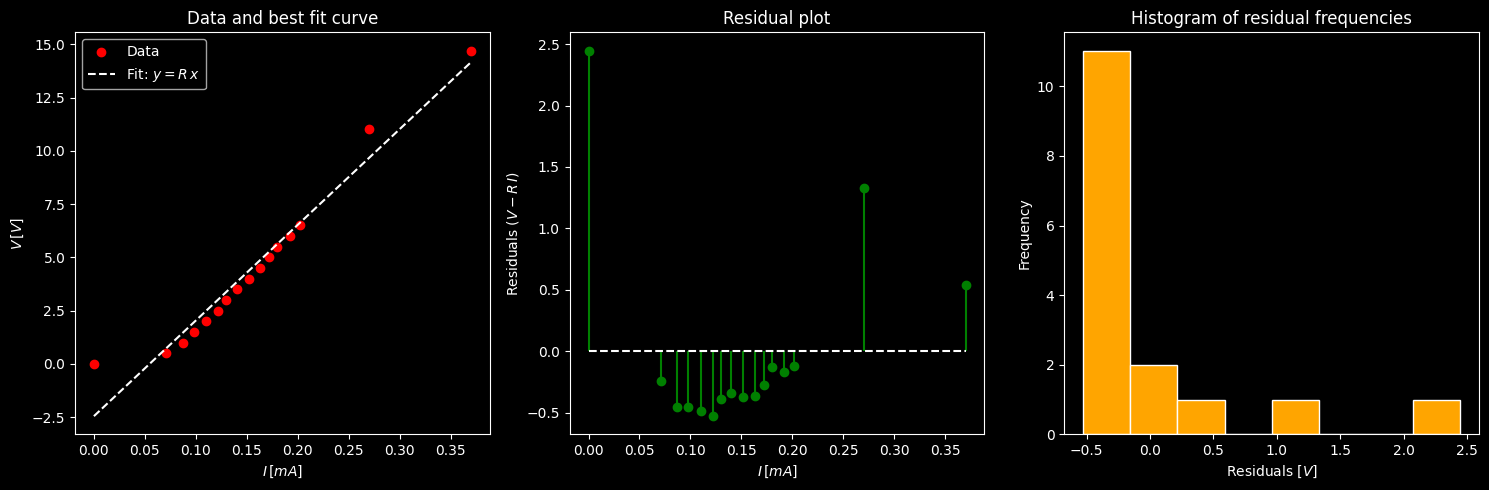

In [24]:
# Plotting new results
fig, (ax_left, ax_right, ax_hist) = plt.subplots(1, 3, figsize = (15, 5))

# Data and fit plot
ax_left.scatter(I_data, V_data, color = 'red', label = 'Data')
ax_left.plot(I_data, R_computed * I_data + q_computed, linestyle = '--', color = 'white', label = r'Fit: $y = R \, x$') # Add q
ax_left.set_xlabel(r'$I \, [mA]$')
ax_left.set_ylabel(r'$V \, [V]$')
ax_left.set_title('Data and best fit curve')
ax_left.legend()

# Residuals plot
res = V_data - (R_computed * I_data + q_computed) # Add q
ax_right.stem(I_data, res, linefmt =  'green', markerfmt = 'green', basefmt = 'w--', bottom = 0)
ax_right.set_xlabel(r'$I \, [mA]$')
ax_right.set_ylabel(r'Residuals $(V - R \, I)$')
ax_right.set_title('Residual plot')

# Residuals histogram plot
ax_hist.hist(res, bins = 'auto', density = False, color = 'orange', edgecolor = 'white')
ax_hist.set_xlabel(r'Residuals $[V]$')
ax_hist.set_ylabel('Frequency')
ax_hist.set_title('Histogram of residual frequencies')

plt.tight_layout()
plt.show()

Let's estimate the errors $\Delta R$ and $\Delta q$ using the jackknife method

In [25]:
def jackknife(I_data, V_data):
    n = len(I_data)

    R_array = np.zeros(n, dtype = np.float32)
    q_array = np.zeros(n, dtype = np.float32)
    RSS_array = np.zeros(n, dtype = np.float32)

    # Leave-one-out loop
    for i in range(n):

        I_jack = np.delete(I_data, i)
        V_jack = np.delete(V_data, i)

        sum_Ij = np.sum(I_jack)
        sum_Vj = np.sum(V_jack)
        sum_I2j = np.sum(I_jack ** 2)
        sum_IVj = np.sum(I_jack * V_jack)
        denom_j = (n - 1.0) * sum_I2j - sum_Ij ** 2.0

        R_jack = ((n - 1.0) * sum_IVj - sum_Ij * sum_Vj) / denom_j
        q_jack = (sum_I2j * sum_Vj - sum_Ij * sum_IVj) / denom_j

        RSS_jack = np.sum((V_jack - R_jack * I_jack - q_jack) ** 2.0)

        R_array[i] = R_jack
        q_array[i] = q_jack
        RSS_array[i] = RSS_jack

    return R_array, q_array, RSS_array

R_array, q_array, RSS_array = jackknife(I_data, V_data)

In [26]:
# Stats for R [V / mA]
meanR = np.mean(R_array)
errR = np.std(R_array)
meanR, errR, errR / meanR * 100.0, R_array

(np.float32(44.866264),
 np.float32(1.4235501),
 np.float32(3.172874),
 array([49.78463 , 44.66373 , 44.557228, 44.61706 , 44.658123, 44.707024,
        44.783657, 44.82973 , 44.86936 , 44.909855, 44.92549 , 44.910248,
        44.941338, 44.93391 , 43.09073 , 42.678104], dtype=float32))

In [27]:
# Stats for q [V]
meanq = np.mean(q_array)
errq = np.std(q_array)
meanq, errq, errq / np.abs(meanq) * 100.0, q_array

(np.float32(-2.4510477),
 np.float32(0.25796035),
 np.float32(10.524493),
 array([-3.4146926, -2.3971317, -2.3659825, -2.3760588, -2.380132 ,
        -2.385352 , -2.4067447, -2.417345 , -2.4209082, -2.4275365,
        -2.4363074, -2.4433641, -2.4454682, -2.4477236, -2.2750435,
        -2.176971 ], dtype=float32))

In [28]:
# Stats for RSS [V ^ 2]
meanRSS = np.mean(RSS_array)
errRSS = np.std(RSS_array)
meanRSS, errRSS, errRSS / meanRSS * 100.0, RSS_array

(np.float32(8.903237),
 np.float32(2.0129147),
 np.float32(22.608795),
 array([1.3562082, 9.645776 , 9.477877 , 9.487481 , 9.450814 , 9.410973 ,
        9.550694 , 9.5908785, 9.561935 , 9.566855 , 9.632298 , 9.692981 ,
        9.680327 , 9.696134 , 7.528775 , 9.12179  ], dtype=float32))